 # Underwater Image Denoising Demo

This notebook applies a **multi-stage denoising pipeline** to a single image.

Pipeline (in order):

1. Gaussian smoothing – remove high-frequency sensor noise.  
2. Median filtering – remove salt-and-pepper / particle speckle.  
3. Bilateral filtering (optional) – smooth homogeneous water regions while preserving edges.  
4. Laplacian high-boost sharpening – restore edge sharpness after smoothing.

Edit the `INPUT_IMAGE` and `OUTPUT_IMAGE` paths in the cell below, then run all cells.


In [1]:
# If you don't have these installed yet, run in a terminal:
# pip install opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(img, title=None, figsize=(6, 5)):
    """Utility to display BGR image with matplotlib."""
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


In [2]:
# ---- Denoising functions (Gaussian -> Median -> Bilateral -> Sharpen) ----

def gaussian_smooth(img, ksize=5, sigma=1.5):
    """Initial smoothing to remove high-frequency sensor noise."""
    ksize = int(ksize) | 1  # make sure it's odd
    return cv2.GaussianBlur(img, (ksize, ksize), sigmaX=sigma, sigmaY=sigma)

def median_filter(img, ksize=3):
    """Remove salt-and-pepper style particle noise while preserving edges."""
    ksize = int(ksize) | 1
    return cv2.medianBlur(img, ksize)

def add_salt_pepper_noise(img, amount=0.02, salt_vs_pepper=0.5, per_channel=False, seed=None):
    """Add random salt-and-pepper noise to an image.

    Args:
        img: Input grayscale or BGR image (numpy array).
        amount: Fraction of pixels to corrupt (0–1); values outside are clipped.
        salt_vs_pepper: Ratio of salt (white) vs pepper (black) noise (0–1).
        per_channel: If True, sample salt/pepper per channel; otherwise apply to all channels at once.
        seed: Optional seed for reproducibility.
    """
    if amount <= 0:
        return img.copy()

    amount = float(np.clip(amount, 0.0, 1.0))
    salt_vs_pepper = float(np.clip(salt_vs_pepper, 0.0, 1.0))

    h, w = img.shape[:2]
    total_pixels = h * w
    n_salt = int(round(total_pixels * amount * salt_vs_pepper))
    n_pepper = int(round(total_pixels * amount * (1.0 - salt_vs_pepper)))

    rng = np.random.default_rng(seed)
    noisy = img.copy()

    def _apply(coords, value, channel=None):
        if img.ndim == 2:
            noisy[coords[0], coords[1]] = value
        elif channel is None:
            noisy[coords[0], coords[1], :] = value
        else:
            noisy[coords[0], coords[1], channel] = value

    if per_channel and img.ndim == 3:
        for c in range(img.shape[2]):
            salt_coords = (
                rng.integers(0, h, n_salt, endpoint=False),
                rng.integers(0, w, n_salt, endpoint=False),
            )
            pepper_coords = (
                rng.integers(0, h, n_pepper, endpoint=False),
                rng.integers(0, w, n_pepper, endpoint=False),
            )
            _apply(salt_coords, 255, channel=c)
            _apply(pepper_coords, 0, channel=c)
    else:
        salt_coords = (
            rng.integers(0, h, n_salt, endpoint=False),
            rng.integers(0, w, n_salt, endpoint=False),
        )
        pepper_coords = (
            rng.integers(0, h, n_pepper, endpoint=False),
            rng.integers(0, w, n_pepper, endpoint=False),
        )
        _apply(salt_coords, 255)
        _apply(pepper_coords, 0)

    return noisy

def bilateral_filter_optional(img, d=0, sigma_color=25, sigma_space=None):
    """
    Edge-preserving smoothing.
    If d <= 0, returns img unchanged (i.e., skip this step).
    """
    if d is None or d <= 0:
        return img
    if sigma_space is None:
        sigma_space = max(10, d * 2)
    return cv2.bilateralFilter(img, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)

def laplacian_highboost(img, strength=0.3):
    """Recover edge sharpness after smoothing by subtracting scaled Laplacian."""
    if strength <= 0:
        return img
    f = img.astype(np.float32)
    lap = cv2.Laplacian(f, ddepth=cv2.CV_32F, ksize=3)
    out = f - strength * lap
    return np.clip(out, 0, 255).astype(np.uint8)
 
def remove_big_spots(img_bgr, thresh=220, k=5):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    inpainted = cv2.inpaint(img_bgr, mask_clean, 3, cv2.INPAINT_TELEA)
    return inpainted

def image_entropy(img_bgr):
    """
    Compute entropy of an image. Converts to uint8 grayscale safely.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = gray.astype(np.uint8)

    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = hist.ravel()

    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]

    return float(-np.sum(p * np.log2(p)))


In [3]:
INPUT_IMAGE = "../data/UnderwaterImageSamples/cuttlefish/gettyimages-115125354-640x640.jpg"
OUTPUT_IMAGE = "output_denoised.jpg"

print("Input image path: ", INPUT_IMAGE)
print("Output image path:", OUTPUT_IMAGE)

Input image path:  ../data/UnderwaterImageSamples/cuttlefish/gettyimages-115125354-640x640.jpg
Output image path: output_denoised.jpg


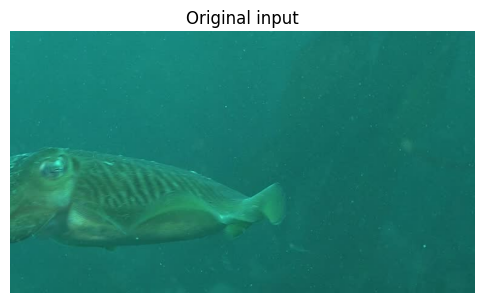

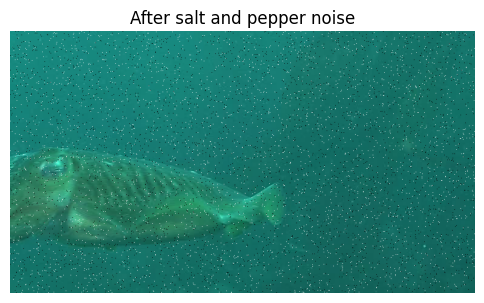

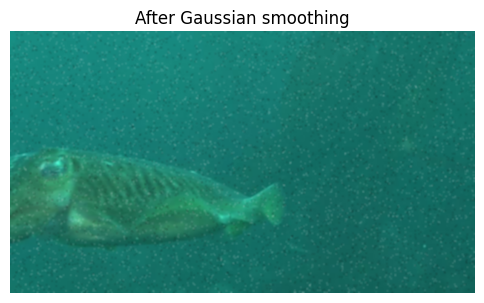

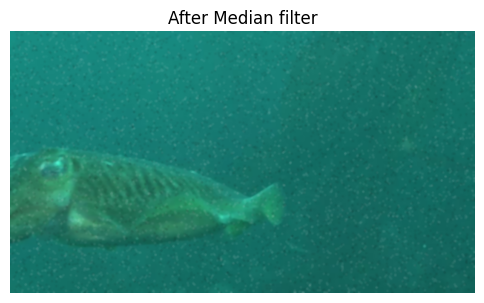

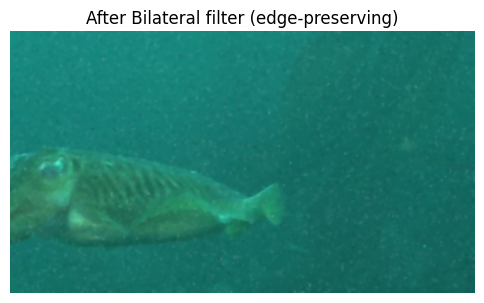

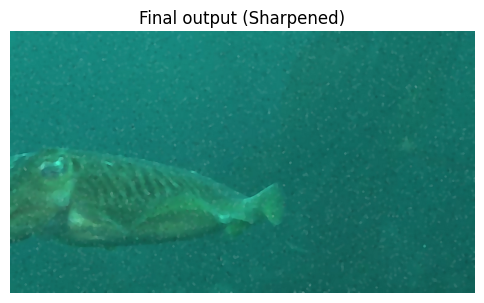

Saved denoised image to: output_denoised.jpg


In [4]:
# 1. Load
img = cv2.imread(INPUT_IMAGE, cv2.IMREAD_COLOR)
if img is None:
    raise FileNotFoundError(f"Could not read image at: {INPUT_IMAGE}")

show_image(img, "Original input")

# add salt and pepper noise
img = add_salt_pepper_noise(img, amount=0.02, salt_vs_pepper=0.5, per_channel=False, seed=None)
show_image(img, "After salt and pepper noise")
cv2.imwrite("after_salt_pepper.jpg", img)

# remove big spots if any
img = remove_big_spots(img, thresh=200, k=5)

# 2. Gaussian smoothing
g = gaussian_smooth(img, ksize=5, sigma=1.5)
show_image(g, "After Gaussian smoothing")
cv2.imwrite("after_gaussian.jpg", g)

# 3. Median filtering
m = median_filter(g, ksize=3)
show_image(m, "After Median filter")
cv2.imwrite("after_median.jpg", m)

# 4. Bilateral (optional) - set d to 0 to skip
b = bilateral_filter_optional(m, d=7, sigma_color=25)
show_image(b, "After Bilateral filter (edge-preserving)")
cv2.imwrite("after_bilateral.jpg", b)

# 5. Sharpen
out = laplacian_highboost(b, strength=0.3)
show_image(out, "Final output (Sharpened)")

# 6. Save
cv2.imwrite(OUTPUT_IMAGE, out)
print("Saved denoised image to:", OUTPUT_IMAGE)


In [5]:
entropies = {
    "Original": image_entropy(img),
    "Gaussian": image_entropy(g),
    "Median":   image_entropy(m),
    "Bilateral": image_entropy(b),
    "Sharpened": image_entropy(out),
}

for name, H in entropies.items():
    print(f"{name} entropy: {H:.3f} bits")

Original entropy: 5.297 bits
Gaussian entropy: 5.388 bits
Median entropy: 5.347 bits
Bilateral entropy: 5.277 bits
Sharpened entropy: 5.351 bits


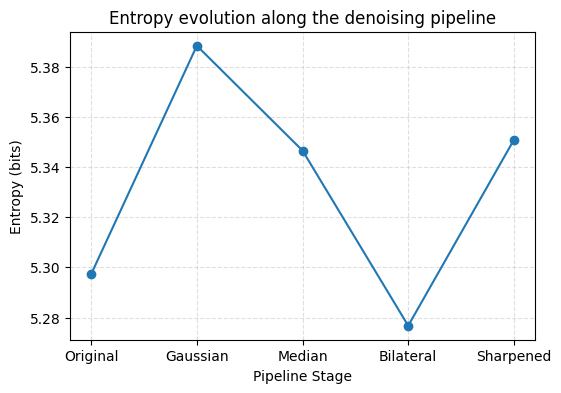

In [6]:
names = list(entropies.keys())
values = [entropies[k] for k in names]

plt.figure(figsize=(6, 4))
plt.plot(names, values, marker="o")
plt.xlabel("Pipeline Stage")
plt.ylabel("Entropy (bits)")
plt.title("Entropy evolution along the denoising pipeline")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()
